# Combined Traditional Features

It combines the HOG feature and RGB colour histogram into one feature vector.

The HOG method was created in `hog.ipynb`, and the colour histogram method was created in `color.ipynb`.

## 1.Import libraries

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from skimage.color import rgb2gray
from skimage.feature import hog

## 2.Load the shared project configuration

It finds the project root and imports `config.py`.

Using the shared configuration avoids personal absolute paths and keeps the notebook working on different computers.

In [2]:
current_path = Path.cwd().resolve()

for parent in [current_path, *current_path.parents]:
    if (parent / "src" / "config.py").exists():
        project_root = parent
        break
else:
    raise FileNotFoundError(
        "Could not find the project root containing src/config.py"
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import config

print("Project root:", project_root)
print("Image size:", config.IMG_SIZE)
print("Training CSV:", config.TRAIN_CSV)

Project root: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group
Image size: (224, 224)
Training CSV: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\data\processed\train.csv


## 3.Load and check a sample image

It selects a sample image from the training set, checks that the file exists, loads it as an RGB image, and displays its basic information.

Change `sample_index` to test another image.

Dataset size: 20000
Sample index: 0
Image path: C:\Users\1\Desktop\COMP9517\Project\9517_assignment_MVP_Group\data\raw\train_mini\07078_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Xylorhiza_orcuttii\f670b8a9-7f74-4424-9b2c-5ed900868df4.jpg
Original size: (281, 500)
Image mode: RGB
Label: 364
Category: Xylorhiza orcuttii


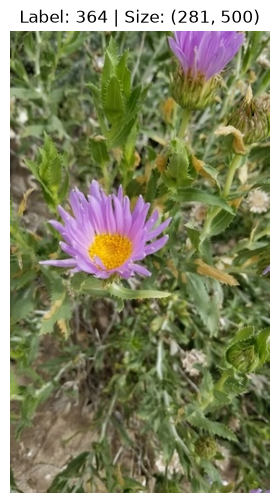

In [3]:
train_df = pd.read_csv(config.TRAIN_CSV)

required_columns = {"file_path", "label"}
missing_columns = required_columns - set(train_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required CSV columns: {sorted(missing_columns)}"
    )

if train_df.empty:
    raise ValueError("The training CSV is empty.")

sample_index = 0

if sample_index < 0 or sample_index >= len(train_df):
    raise IndexError(
        f"sample_index must be between 0 and {len(train_df) - 1}"
    )

sample_row = train_df.iloc[sample_index]
sample_path = config.DATA_RAW_ROOT / sample_row["file_path"]

if not sample_path.exists():
    raise FileNotFoundError(
        f"Sample image was not found: {sample_path}"
    )

with Image.open(sample_path) as image:
    sample_image = image.convert("RGB")

print("Dataset size:", len(train_df))
print("Sample index:", sample_index)
print("Image path:", sample_path)
print("Original size:", sample_image.size)
print("Image mode:", sample_image.mode)
print("Label:", sample_row["label"])

if "category_name" in train_df.columns:
    print("Category:", sample_row["category_name"])

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.axis("off")
plt.title(
    f"Label: {sample_row['label']} | "
    f"Size: {sample_image.size}"
)
plt.show()

## 4.Define the HOG feature function

This function uses the same HOG settings as `hog.ipynb`.

It resizes the image, converts it to grayscale, and returns a fixed-length `float32` feature vector.

In [4]:
def extract_hog_feature(image):
    resized_image = image.convert("RGB").resize(config.IMG_SIZE)
    image_array = np.asarray(resized_image)
    gray_image = rgb2gray(image_array)

    feature = hog(
        gray_image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    return feature.astype(np.float32)

## 5.Define the colour histogram function

This function uses the same RGB histogram method as `color.ipynb`.

It resizes the image, calculates a 32-bin histogram for each RGB channel, normalises each histogram, and combines them into one `float32` feature vector.

In [5]:
def extract_colour_feature(image, bins=32):
    resized_image = image.convert("RGB").resize(config.IMG_SIZE)
    image_array = np.asarray(resized_image)

    channel_features = []

    for channel in range(3):
        histogram, _ = np.histogram(
            image_array[:, :, channel],
            bins=bins,
            range=(0, 256)
        )

        histogram = histogram.astype(np.float32)

        if histogram.sum() > 0:
            histogram /= histogram.sum()

        channel_features.append(histogram)

    feature = np.concatenate(channel_features)

    return feature.astype(np.float32)

## 6.Define the combined feature function

This function extracts the HOG feature and RGB colour histogram from the same image.

The two feature vectors are then joined into one fixed-length `float32` vector.

In [6]:
def extract_combined_feature(image):
    hog_feature = extract_hog_feature(image)
    colour_feature = extract_colour_feature(image)

    combined_feature = np.concatenate(
        [hog_feature, colour_feature]
    )

    return combined_feature.astype(np.float32)

## 7.Test the combined feature

It extracts the HOG, colour, and combined features from the sample image.

It checks the output shape, data type, and whether the combined feature contains invalid values.

In [7]:
hog_feature = extract_hog_feature(sample_image)
colour_feature = extract_colour_feature(sample_image)
combined_feature = extract_combined_feature(sample_image)

print("HOG shape:", hog_feature.shape)
print("Colour shape:", colour_feature.shape)
print("Combined shape:", combined_feature.shape)
print("Combined dtype:", combined_feature.dtype)
print("Contains NaN:", np.isnan(combined_feature).any())
print("Contains infinity:", np.isinf(combined_feature).any())

HOG shape: (6084,)
Colour shape: (96,)
Combined shape: (6180,)
Combined dtype: float32
Contains NaN: False
Contains infinity: False


## 8.Check the combined feature sections

It checks that the combined feature keeps the correct order.

The first part should match the HOG feature, and the remaining part should match the colour feature.

In [8]:
hog_length = len(hog_feature)
colour_length = len(colour_feature)

hog_section_matches = np.array_equal(
    combined_feature[:hog_length],
    hog_feature
)

colour_section_matches = np.array_equal(
    combined_feature[hog_length:],
    colour_feature
)

print("HOG section matches:", hog_section_matches)
print("Colour section matches:", colour_section_matches)
print("Expected length:", hog_length + colour_length)
print("Actual length:", len(combined_feature))

HOG section matches: True
Colour section matches: True
Expected length: 6180
Actual length: 6180


## 9.Test images from different classes

It selects sample images from different labels and checks whether the combined feature has the same shape and data type for every image.

In [9]:
test_rows = train_df.drop_duplicates(subset="label").head(5)

feature_lengths = []

for _, row in test_rows.iterrows():
    image_path = config.DATA_RAW_ROOT / row["file_path"]

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image was not found: {image_path}"
        )

    with Image.open(image_path) as image:
        test_image = image.convert("RGB")

    feature = extract_combined_feature(test_image)
    feature_lengths.append(len(feature))

    category = (
        row["category_name"]
        if "category_name" in train_df.columns
        else "N/A"
    )

    print(
        f"Label: {row['label']}, "
        f"Category: {category}, "
        f"Shape: {feature.shape}, "
        f"Dtype: {feature.dtype}, "
        f"Finite: {np.isfinite(feature).all()}"
    )

print("All feature lengths:", feature_lengths)
print("Same length:", len(set(feature_lengths)) == 1)

Label: 364, Category: Xylorhiza orcuttii, Shape: (6180,), Dtype: float32, Finite: True
Label: 251, Category: Sceloporus orcutti, Shape: (6180,), Dtype: float32, Finite: True
Label: 449, Category: Malvaviscus arboreus, Shape: (6180,), Dtype: float32, Finite: True
Label: 404, Category: Lysimachia clethroides, Shape: (6180,), Dtype: float32, Finite: True
Label: 199, Category: Pycnonotus leucotis, Shape: (6180,), Dtype: float32, Finite: True
All feature lengths: [6180, 6180, 6180, 6180, 6180]
Same length: True


## 10.Final validation

It performs a final check of the combined feature before it is used in the feature caching pipeline.

In [10]:
expected_hog_length = 6084
expected_colour_length = 96
expected_combined_length = 6180

checks = {
    "HOG length is correct":
        len(hog_feature) == expected_hog_length,

    "Colour length is correct":
        len(colour_feature) == expected_colour_length,

    "Combined length is correct":
        len(combined_feature) == expected_combined_length,

    "Combined dtype is float32":
        combined_feature.dtype == np.float32,

    "All values are finite":
        np.isfinite(combined_feature).all(),

    "HOG section matches":
        np.array_equal(
            combined_feature[:expected_hog_length],
            hog_feature
        ),

    "Colour section matches":
        np.array_equal(
            combined_feature[expected_hog_length:],
            colour_feature
        )
}

for check_name, passed in checks.items():
    print(f"{check_name}: {passed}")

print("\nAll checks passed:", all(checks.values()))

HOG length is correct: True
Colour length is correct: True
Combined length is correct: True
Combined dtype is float32: True
All values are finite: True
HOG section matches: True
Colour section matches: True

All checks passed: True


## Summary

The HOG and RGB colour features were successfully combined into one feature vector.

- HOG feature shape: `(6084,)`
- Colour feature shape: `(96,)`
- Combined feature shape: `(6180,)`
- Data type: `float32`

The combined feature was tested on images from different classes. All tested images produced the same feature length, and no missing or infinite values were found.

The combined feature can now be used in the feature caching step.